# ADE20K Multi-Class Segmentation: Featherweight MobileNetV2 U-Net vs. Heavyweight DeepLabV3-ResNet50 (Bhanu Prasad)

## A. Workspace.

In [1]:
# ================================================================
# A. Workspace: guarded installs, imports, fixed seeds.
# ================================================================
# Colab already ships torch/torchvision/matplotlib, so we install
# only what is genuinely missing. Installs run through subprocess
# with check=True: a broken wheel raises a loud CalledProcessError
# instead of the silent half-install that "!pip" can leave behind.
import importlib.util
import subprocess
import sys


def ensure_pkg(module_name, pip_name):
    """Install pip_name only when module_name cannot already be imported."""
    if importlib.util.find_spec(module_name) is None:
        subprocess.run(
            [sys.executable, "-m", "pip", "install", "--quiet", pip_name],
            check=True,
        )
        print("installed:", pip_name)
    else:
        print("already present:", module_name)


# Each entry pairs the import name with the PyPI name (they differ!).
for module_name, pip_name in [
    ("segmentation_models_pytorch", "segmentation-models-pytorch"),
    ("pycocotools", "pycocotools"),
    ("cv2", "opencv-python-headless"),
]:
    ensure_pkg(module_name, pip_name)

import json
import random
import sqlite3
import time
import zipfile
from collections import defaultdict
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import segmentation_models_pytorch as smp
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from pycocotools import mask as coco_mask
from torch.utils.data import DataLoader, Dataset

# ---- reproducibility: one seed, planted everywhere -------------
# 2093 is arbitrary but FIXED; every stochastic component below
# (python, numpy, torch CPU, torch CUDA) draws from it so reruns
# of this notebook produce comparable numbers.
SEED = 2093
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
# Deterministic cuDNN kernels cost a little speed but keep the
# featherweight-vs-heavyweight comparison fair across reruns.
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch", torch.__version__, "| torchvision", torchvision.__version__)
print("compute device:", DEVICE)

installed: segmentation-models-pytorch
already present: pycocotools
already present: cv2
torch 2.11.0+cu128 | torchvision 0.26.0+cu128
compute device: cuda


## B. Settings.

In [2]:
# ================================================================
# B. Settings: one JSON blob is the single source of truth.
# ================================================================
# Every knob lives in ONE JSON string parsed with json.loads.
# Why JSON rather than loose python variables? (1) the whole run
# is reproducible from a copy-pasteable block, (2) it cleanly
# separates configuration from code, and (3) the same blob could
# be written to disk and re-loaded by a follow-up experiment.
SETTINGS_JSON = """
{
  "data": {
    "zip_name": "RMDS_segmentation_dataset_ADE20K_350.zip",
    "img_size": 384,
    "num_classes": 5,
    "class_names": ["background", "person", "car", "book", "airplane"],
    "coco_id_to_label": {"4": 1, "9": 2, "40": 3, "59": 4}
  },
  "train": {
    "batch_size": 11,
    "num_workers": 6,
    "epochs_cap": 32,
    "patience": 8,
    "lr_unet": 3e-4,
    "lr_dlv3": 5e-5,
    "weight_decay": 5e-4,
    "sched_gamma": 0.95,
    "focal_gamma": 2.0
  },
  "out": {
    "art_dir": "mnv2_vs_r50",
    "unet_ckpt": "unet_mnv2.pth",
    "dlv3_ckpt": "dlv3_r50_tuned.pth",
    "table_csv": "result_table.csv"
  }
}
"""
SETTINGS = json.loads(SETTINGS_JSON)

# JSON object keys are always strings, so the category-id lookup is
# rebuilt once with integer keys here. The mapping compresses the
# sparse ADE20K/COCO category ids {4, 9, 40, 59} into the dense
# label space {1, 2, 3, 4}; label 0 stays reserved for background.
# This is a MULTI-CLASS problem: collapsing to binary fg/bg would
# throw away exactly the information the assignment grades.
COCO_TO_LABEL = {int(k): v for k, v in SETTINGS["data"]["coco_id_to_label"].items()}
CLASS_NAMES = SETTINGS["data"]["class_names"]
NUM_CLASSES = SETTINGS["data"]["num_classes"]
IMG_SIZE = SETTINGS["data"]["img_size"]

# ---- figure conventions used by every plot below ---------------
ACCENT = "#B23A48"                       # the single accent colour
GREYS = ["#e6e6e6", "#b3b3b3", "#808080", "#4d4d4d"]  # everything else
CLASS_COLOURS = [GREYS[0], ACCENT, GREYS[1], GREYS[2], GREYS[3]]
ACCENT_RGB = (178, 58, 72)               # B2 3A 48 in decimal, for cv2

# ---- locate and unpack the dataset zip --------------------------
# We check a short, explicit list of the usual Colab / local spots.
zip_name = SETTINGS["data"]["zip_name"]
candidate_dirs = [Path.cwd(), Path("/content"), Path("/content/drive/MyDrive")]
zip_path = None
for d in candidate_dirs:
    if (d / zip_name).is_file():
        zip_path = d / zip_name
        break
if zip_path is None:
    raise FileNotFoundError(
        f"{zip_name} not found in {[str(d) for d in candidate_dirs]}; "
        "copy the archive next to this notebook first."
    )

EXTRACT_DIR = Path.cwd() / "ade_extracted"
if not EXTRACT_DIR.exists():
    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(EXTRACT_DIR)
    print("archive expanded ->", EXTRACT_DIR.name)
else:
    print("archive already expanded ->", EXTRACT_DIR.name)

# The zip may or may not carry a top-level folder, so we anchor on
# the annotation files themselves instead of guessing directories.
ANN_PATHS = {
    "train": next(EXTRACT_DIR.rglob("instances_train*.json")),
    "val": next(EXTRACT_DIR.rglob("instances_val*.json")),
}
DATA_BASE = ANN_PATHS["train"].parent
print("dataset base folder:", DATA_BASE.name)


def resolve_image_path(split, file_name):
    """Return the on-disk path of an image, tolerating layout quirks."""
    for cand in (
        DATA_BASE / split / file_name,
        DATA_BASE / split / "images" / file_name,
        DATA_BASE / "images" / split / file_name,
    ):
        if cand.is_file():
            return cand
    # Last resort: a targeted recursive glob on the file name.
    hits = list(EXTRACT_DIR.rglob(file_name))
    if hits:
        return hits[0]
    raise FileNotFoundError(f"{split}/{file_name} missing from the archive")


# Test images carry no annotations, so they are just a file listing.
TEST_DIR = DATA_BASE / "test"
if not TEST_DIR.is_dir():
    TEST_DIR = next(p for p in EXTRACT_DIR.rglob("test") if p.is_dir())
TEST_IMAGES = sorted(
    [p for p in TEST_DIR.rglob("*") if p.suffix.lower() in {".jpg", ".jpeg", ".png"}]
)
print("held-out test images found:", len(TEST_IMAGES))

ART_DIR = Path.cwd() / SETTINGS["out"]["art_dir"]
ART_DIR.mkdir(exist_ok=True)
print("artifacts will be written under:", ART_DIR.name + "/")

archive expanded -> ade_extracted
dataset base folder: ade_extracted
held-out test images found: 30
artifacts will be written under: mnv2_vs_r50/


## C. Annotations To Masks: SQLite Blob Store.

In [3]:
# ================================================================
# C. COCO RLE annotations -> uint8 class masks -> one SQLite file.
# ================================================================
# WHY A SINGLE-FILE DATABASE INSTEAD OF 700 LOOSE PNG FILES?
# On Google Drive (and most network filesystems) every tiny file
# costs its own metadata round-trip, so thousands of small reads
# crawl along at a few files per second. One .db file is a single
# open handle whose pages the OS caches aggressively; SQLite also
# allows many concurrent READERS, which is exactly the DataLoader
# access pattern. The stdlib ships sqlite3, so nothing to install.

MASK_DB = Path.cwd() / "mask_store.sqlite"


def load_split_index(split):
    """Parse one instances_*.json into image records + per-image anns."""
    with open(ANN_PATHS[split]) as fh:
        payload = json.load(fh)
    images = {im["id"]: im for im in payload["images"]}
    anns_by_image = defaultdict(list)
    for ann in payload["annotations"]:
        anns_by_image[ann["image_id"]].append(ann)
    return images, anns_by_image


def decode_segmentation(seg, h, w):
    """Decode a COCO segmentation (RLE dict or polygon list) to 0/1."""
    if isinstance(seg, dict):
        rle = seg
        if isinstance(rle.get("counts"), list):
            # "uncompressed" RLE still needs packing before decode
            rle = coco_mask.frPyObjects(rle, h, w)
    else:
        rles = coco_mask.frPyObjects(seg, h, w)
        rle = coco_mask.merge(rles)
    return coco_mask.decode(rle).astype(np.uint8)


def paint_semantic_mask(h, w, anns):
    """Rasterise one image's annotations into a uint8 label canvas.

    OVERLAP RULE: we sweep the annotation list in REVERSE order and
    only write onto pixels that are still background, so wherever
    two objects overlap the LAST-listed annotation wins. The choice
    is entirely arbitrary -- the JSON carries no depth ordering, so
    SOME tie-break has to be committed to; we pick this one, apply
    it uniformly to train and val, and count every contested pixel
    so the scale of the arbitrariness is printed, not hidden.
    """
    canvas = np.zeros((h, w), dtype=np.uint8)
    contested = 0
    for ann in reversed(anns):
        label = COCO_TO_LABEL.get(ann["category_id"])
        if label is None:
            continue  # category outside our 4 foreground classes
        obj = decode_segmentation(ann["segmentation"], h, w)
        # pixels this object covers that somebody later in the file
        # (processed earlier in this reversed sweep) already claimed
        contested += int(((obj == 1) & (canvas != 0)).sum())
        canvas[(obj == 1) & (canvas == 0)] = label
    return canvas, contested


# ---- build (or reuse) the mask store ----------------------------
SPLIT_INDEX = {}
for split in ("train", "val"):
    SPLIT_INDEX[split] = load_split_index(split)

if not MASK_DB.exists():
    t0 = time.time()
    con = sqlite3.connect(MASK_DB)
    con.execute(
        "CREATE TABLE masks (key TEXT PRIMARY KEY, h INT, w INT, png BLOB)"
    )
    total_contested = 0
    for split in ("train", "val"):
        images, anns_by_image = SPLIT_INDEX[split]
        for image_id, rec in images.items():
            canvas, contested = paint_semantic_mask(
                rec["height"], rec["width"], anns_by_image.get(image_id, [])
            )
            total_contested += contested
            # PNG is lossless AND tiny for flat label rasters; the
            # blob goes straight into the row, no side files at all.
            ok, buf = cv2.imencode(".png", canvas)
            assert ok, "png encode failed"
            con.execute(
                "INSERT INTO masks VALUES (?, ?, ?, ?)",
                (f"{split}/{rec['file_name']}",
                 rec["height"], rec["width"], buf.tobytes()),
            )
    con.commit()
    con.close()
    print(f"mask store built in {time.time() - t0:.1f}s")
    print("overlap collisions resolved by the last-listed-wins rule:",
          total_contested, "pixels")
else:
    print("mask store already on disk, reusing it")

con = sqlite3.connect(MASK_DB)
n_rows = con.execute("SELECT COUNT(*) FROM masks").fetchone()[0]
db_mb = MASK_DB.stat().st_size / 1e6
con.close()
print(f"mask rows: {n_rows} | single-file store size: {db_mb:.1f} MB")


def fetch_mask(connection, key):
    """Decode one stored PNG blob back into a uint8 label array."""
    row = connection.execute(
        "SELECT png FROM masks WHERE key = ?", (key,)
    ).fetchone()
    if row is None:
        raise KeyError(key)
    return cv2.imdecode(np.frombuffer(row[0], np.uint8), cv2.IMREAD_UNCHANGED)

mask store built in 13.4s
overlap collisions resolved by the last-listed-wins rule: 0 pixels
mask rows: 700 | single-file store size: 2.1 MB


## D. Exploratory Views.

In [4]:
# ================================================================
# D1. Gather the numbers every exploratory view will draw from.
# ================================================================
# One read-only pass over the training split collects: per-class
# pixel totals, objects-per-image counts, image brightness paired
# with the dominant foreground class, class co-occurrence, and the
# biggest book/airplane instances (both are scarce in ADE20K, so
# their largest examples deserve a dedicated look).
train_images, train_anns = SPLIT_INDEX["train"]

pixel_totals = np.zeros(NUM_CLASSES, dtype=np.int64)
objects_per_image = {c: [] for c in range(1, NUM_CLASSES)}
brightness_rows = []            # (mean grey level, dominant fg class name)
cooccur = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64)
instance_ledger = []            # (area_px, class label, image_id, ann)

eda_con = sqlite3.connect(MASK_DB)
for image_id, rec in train_images.items():
    mask = fetch_mask(eda_con, f"train/{rec['file_name']}")
    counts = np.bincount(mask.ravel(), minlength=NUM_CLASSES)
    pixel_totals += counts

    # dominant foreground class = most pixels among labels 1..4
    fg = counts[1:]
    dom = CLASS_NAMES[1 + int(fg.argmax())] if fg.sum() > 0 else "no-fg"
    img = cv2.imread(str(resolve_image_path("train", rec["file_name"])))
    grey = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    brightness_rows.append((float(grey.mean()), dom))

    # object counts + presence sets straight from the annotations
    per_class = defaultdict(int)
    for ann in train_anns.get(image_id, []):
        label = COCO_TO_LABEL.get(ann["category_id"])
        if label is None:
            continue
        per_class[label] += 1
        area = float(ann.get("area", 0.0))
        instance_ledger.append((area, label, image_id, ann))
    for c, n in per_class.items():
        objects_per_image[c].append(n)
    present = sorted(per_class)
    for a in present:
        for b in present:
            if a != b:
                cooccur[a, b] += 1
eda_con.close()

pixel_share = pixel_totals / pixel_totals.sum()
share_df = pd.DataFrame(
    {"class": CLASS_NAMES, "pixels": pixel_totals,
     "share_pct": (pixel_share * 100).round(3)}
)
print(share_df.to_string(index=False))
print("\nimages per split: train",
      len(train_images), "| val", len(SPLIT_INDEX["val"][0]))

     class   pixels  share_pct
background 86246010     93.545
    person  3460166      3.753
       car  2111519      2.290
      book   266028      0.289
  airplane   113628      0.123

images per split: train 350 | val 350


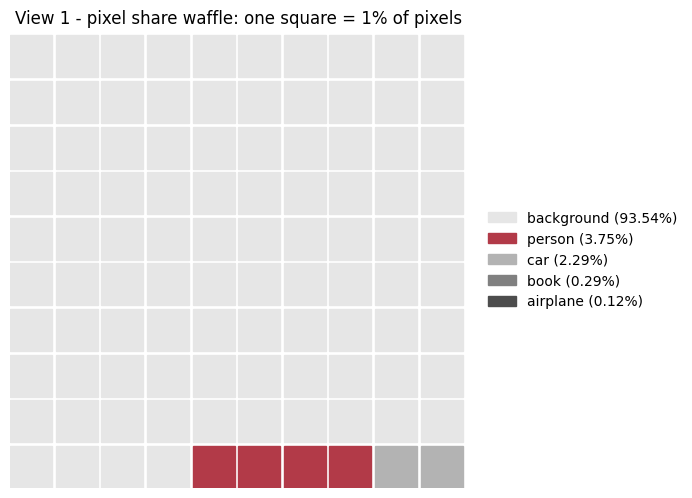

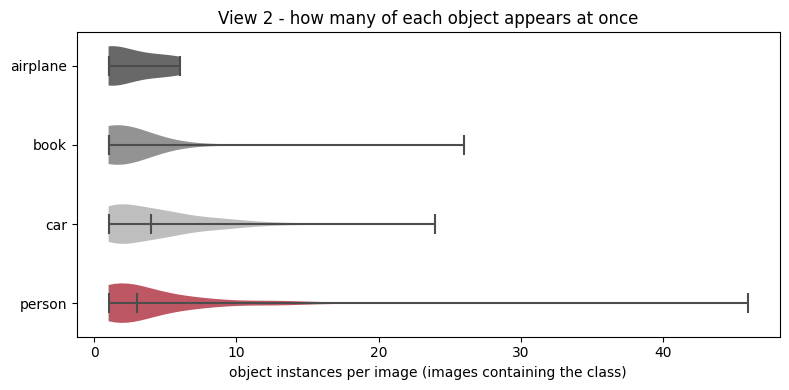

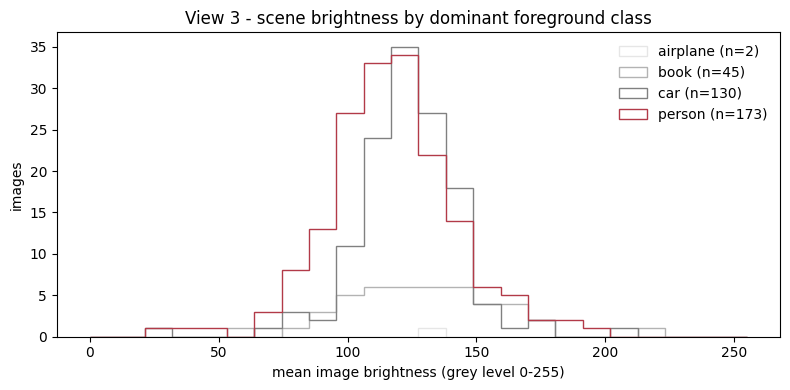

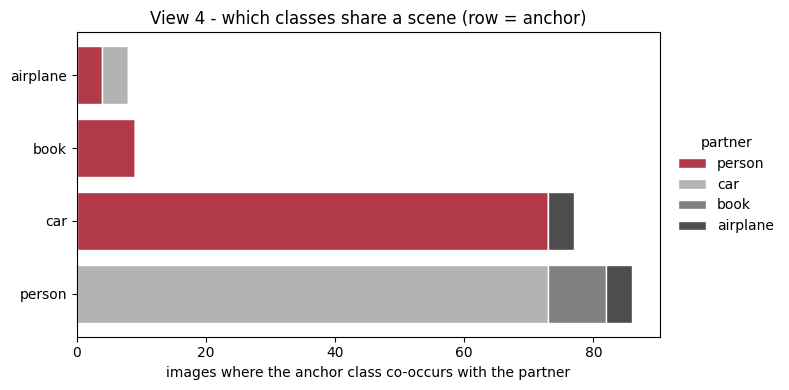

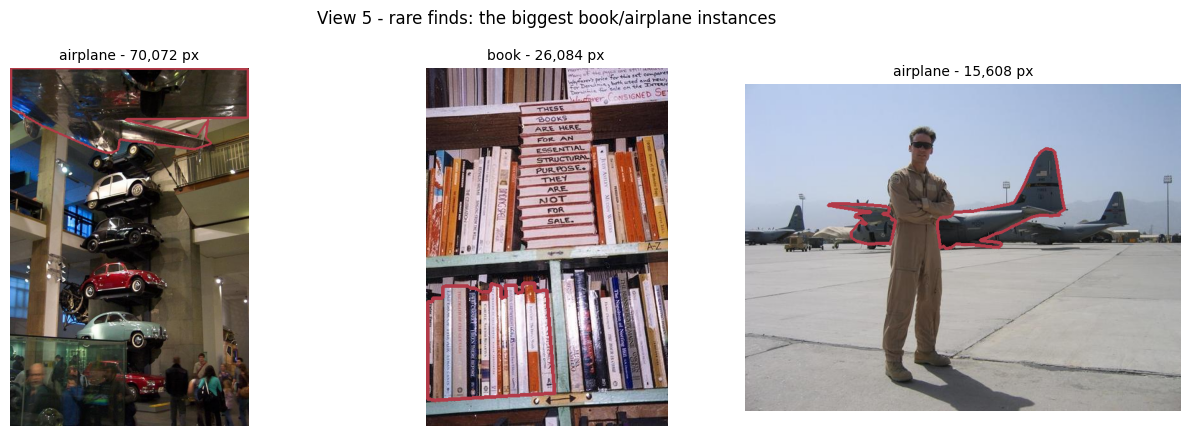

In [5]:
# ================================================================
# D2. Render the exploratory views (all accent-#B23A48 + greys,
#     horizontal-first layouts).
# ================================================================

# ---- view 1: 10x10 waffle grid of pixel share --------------------
# Each of the 100 squares represents exactly 1% of all annotated
# pixels; squares are allocated by largest remainder so they always
# sum to 100 even after rounding.
quota = pixel_share * 100
squares = np.floor(quota).astype(int)
leftovers = np.argsort(quota - squares)[::-1]
i = 0
while squares.sum() < 100:
    squares[leftovers[i % NUM_CLASSES]] += 1
    i += 1
cell_labels = np.repeat(np.arange(NUM_CLASSES), squares).reshape(10, 10)

fig, ax = plt.subplots(figsize=(6.5, 5.2))
for (r, cidx), lab in np.ndenumerate(cell_labels):
    ax.add_patch(plt.Rectangle((cidx, 9 - r), 0.92, 0.92,
                               color=CLASS_COLOURS[lab]))
ax.set_xlim(0, 10); ax.set_ylim(0, 10)
ax.set_aspect("equal"); ax.axis("off")
handles = [plt.Rectangle((0, 0), 1, 1, color=CLASS_COLOURS[c])
           for c in range(NUM_CLASSES)]
ax.legend(handles, [f"{n} ({quota[c]:.2f}%)"
                    for c, n in enumerate(CLASS_NAMES)],
          loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
ax.set_title("View 1 - pixel share waffle: one square = 1% of pixels")
plt.tight_layout(); plt.show()
# Reading: the grid is dominated by grey background squares -- this
# imbalance is precisely why the focal loss appears in section G.

# ---- view 2: horizontal violins of objects-per-image -------------
fig, ax = plt.subplots(figsize=(8, 4))
data = [objects_per_image[c] if objects_per_image[c] else [0]
        for c in range(1, NUM_CLASSES)]
parts = ax.violinplot(data, vert=False, showmedians=True)
for body, c in zip(parts["bodies"], range(1, NUM_CLASSES)):
    body.set_facecolor(CLASS_COLOURS[c]); body.set_alpha(0.85)
for k in ("cmedians", "cbars", "cmins", "cmaxes"):
    parts[k].set_color("#4d4d4d")
ax.set_yticks(range(1, NUM_CLASSES), CLASS_NAMES[1:])
ax.set_xlabel("object instances per image (images containing the class)")
ax.set_title("View 2 - how many of each object appears at once")
plt.tight_layout(); plt.show()
# Reading: person skews to multi-instance crowds while airplane is
# almost always a lone object -- crowding stresses the overlap rule.

# ---- view 3: brightness histogram split by dominant fg class -----
fig, ax = plt.subplots(figsize=(8, 4))
groups = sorted({d for _, d in brightness_rows})
palette = {}
for g in groups:
    if g == "person":
        palette[g] = ACCENT           # accent goes to the biggest class
    else:
        palette[g] = GREYS[(len(palette)) % len(GREYS)]
for g in groups:
    vals = [b for b, d in brightness_rows if d == g]
    ax.hist(vals, bins=24, range=(0, 255), histtype="step", lw=2,
            color=palette[g], label=f"{g} (n={len(vals)})")
ax.set_xlabel("mean image brightness (grey level 0-255)")
ax.set_ylabel("images")
ax.legend(frameon=False)
ax.set_title("View 3 - scene brightness by dominant foreground class")
plt.tight_layout(); plt.show()
# Reading: indoor-leaning classes (book) sit dimmer than outdoor
# ones (car, airplane) -- a hint that photometric jitter helps.

# ---- view 4: stacked co-occurrence bars, anchored per class ------
fig, ax = plt.subplots(figsize=(8, 4))
anchors = list(range(1, NUM_CLASSES))
left = np.zeros(len(anchors))
for partner in anchors:
    seg = np.array([cooccur[a, partner] if a != partner else 0
                    for a in anchors], dtype=float)
    ax.barh([CLASS_NAMES[a] for a in anchors], seg, left=left,
            color=CLASS_COLOURS[partner], edgecolor="white",
            label=CLASS_NAMES[partner])
    left += seg
ax.set_xlabel("images where the anchor class co-occurs with the partner")
ax.legend(title="partner", frameon=False,
          loc="center left", bbox_to_anchor=(1.01, 0.5))
ax.set_title("View 4 - which classes share a scene (row = anchor)")
plt.tight_layout(); plt.show()
# Reading: person co-occurs with everything; book+airplane together
# is essentially absent, so those confusions should stay rare.

# ---- view 5: rare finds -- largest book and airplane instances ----
rare = [entry for entry in instance_ledger if entry[1] in (3, 4)]
rare.sort(key=lambda entry: entry[0], reverse=True)
picked, seen_imgs = [], set()
for entry in rare:
    if entry[2] not in seen_imgs:
        picked.append(entry); seen_imgs.add(entry[2])
    if len(picked) == 3:
        break

fig, axes = plt.subplots(1, 3, figsize=(13, 4.4))
for ax, (area, label, image_id, ann) in zip(axes, picked):
    rec = train_images[image_id]
    img = cv2.cvtColor(
        cv2.imread(str(resolve_image_path("train", rec["file_name"]))),
        cv2.COLOR_BGR2RGB)
    obj = decode_segmentation(ann["segmentation"],
                              rec["height"], rec["width"])
    contours, _ = cv2.findContours(obj, cv2.RETR_EXTERNAL,
                                   cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(img, contours, -1, ACCENT_RGB, 4)
    ax.imshow(img); ax.axis("off")
    ax.set_title(f"{CLASS_NAMES[label]} - {int(area):,} px", fontsize=10)
fig.suptitle("View 5 - rare finds: the biggest book/airplane instances")
plt.tight_layout(); plt.show()
# Reading: even the LARGEST examples of the two rare classes are a
# handful of images -- per-class IoU on book/airplane will be the
# hardest numbers in the result table.

## E. Reusable Preprocessing Tool And Data Pipeline.

In [6]:
# ================================================================
# E. PrepKit (the reusable preprocessing tool) + SQLite-backed
#    Dataset + DataLoaders.
# ================================================================


class PrepKit:
    """One preprocessing tool reused by training, validation, EDA
    replays and raw test images alike.

    Contract: __call__(bgr_image, mask=None) -> (float tensor CHW,
    long tensor HW or None). Images are resized bilinearly, masks
    with NEAREST neighbour (bilinear would invent label values like
    2.5 on class borders). Normalisation uses the ImageNet mean/std
    that both pretrained encoders were originally fed.
    """

    MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)

    def __init__(self, size, augment=False):
        self.size = size
        self.augment = augment

    def __call__(self, bgr, mask=None):
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        rgb = cv2.resize(rgb, (self.size, self.size),
                         interpolation=cv2.INTER_LINEAR)
        if mask is not None:
            mask = cv2.resize(mask, (self.size, self.size),
                              interpolation=cv2.INTER_NEAREST)
        if self.augment:
            # geometric flip must hit image AND mask identically
            if np.random.rand() < 0.5:
                rgb = np.ascontiguousarray(rgb[:, ::-1])
                if mask is not None:
                    mask = np.ascontiguousarray(mask[:, ::-1])
            # photometric jitter touches the image only
            if np.random.rand() < 0.5:
                gain = np.random.uniform(0.85, 1.15)
                rgb = np.clip(rgb.astype(np.float32) * gain,
                              0, 255).astype(np.uint8)
        x = (rgb.astype(np.float32) / 255.0 - self.MEAN) / self.STD
        x = torch.from_numpy(x.transpose(2, 0, 1))
        y = None if mask is None else torch.from_numpy(mask.astype(np.int64))
        return x, y


class MaskVaultDataset(Dataset):
    """Pairs disk images with masks pulled from the SQLite store.

    sqlite3 connections must never cross a fork boundary, so the
    connection starts as None and every worker opens its OWN read-only
    handle on first __getitem__ -- with num_workers=6 that gives six
    independent readers hitting one shared page cache.
    """

    def __init__(self, split, prep):
        images, _ = SPLIT_INDEX[split]
        self.split = split
        self.records = sorted(images.values(), key=lambda r: r["file_name"])
        self.prep = prep
        self._conn = None  # per-process lazy handle

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        if self._conn is None:
            self._conn = sqlite3.connect(
                f"file:{MASK_DB}?mode=ro", uri=True, check_same_thread=False
            )
        rec = self.records[idx]
        bgr = cv2.imread(str(resolve_image_path(self.split, rec["file_name"])))
        mask = fetch_mask(self._conn, f"{self.split}/{rec['file_name']}")
        x, y = self.prep(bgr, mask)
        return x, y


train_ds = MaskVaultDataset("train", PrepKit(IMG_SIZE, augment=True))
val_ds = MaskVaultDataset("val", PrepKit(IMG_SIZE, augment=False))

train_loader = DataLoader(
    train_ds,
    batch_size=SETTINGS["train"]["batch_size"],
    shuffle=True,
    num_workers=SETTINGS["train"]["num_workers"],
    pin_memory=True,
    persistent_workers=SETTINGS["train"]["num_workers"] > 0,
    drop_last=False,
)
val_loader = DataLoader(
    val_ds,
    batch_size=SETTINGS["train"]["batch_size"],
    shuffle=False,
    num_workers=SETTINGS["train"]["num_workers"],
    pin_memory=True,
    persistent_workers=SETTINGS["train"]["num_workers"] > 0,
)

xb, yb = next(iter(DataLoader(train_ds, batch_size=2, num_workers=0)))
print("pipeline smoke test | image batch:", tuple(xb.shape),
      "| mask batch:", tuple(yb.shape),
      "| labels present:", sorted(torch.unique(yb).tolist()))

pipeline smoke test | image batch: (2, 3, 384, 384) | mask batch: (2, 384, 384) | labels present: [0, 1, 2, 4]


## F. Two Models: 7M Featherweight Vs 40M Heavyweight.

In [7]:
# ================================================================
# F. Model A (student-trained) and Model B (pretrained, tuned).
# ================================================================
# The research angle of this notebook: does a ~6x parameter budget
# buy a proportional accuracy gain on a 350-image problem?
#
#  * Model A -- smp.Unet on a mobilenet_v2 encoder (ImageNet init),
#    trained END-TO-END by us: every weight, encoder included,
#    receives gradients at lr=3e-4. This is the student-trained
#    featherweight.
#  * Model B -- torchvision deeplabv3_resnet50 pretrained on COCO,
#    classifier heads swapped to 5 classes, then the WHOLE network
#    fine-tuned at the deliberately low lr=5e-5 so the pretrained
#    representation is nudged rather than bulldozed.


def build_unet_mnv2():
    return smp.Unet(
        encoder_name="mobilenet_v2",
        encoder_weights="imagenet",
        in_channels=3,
        classes=NUM_CLASSES,
    )


def build_dlv3_r50():
    weights = torchvision.models.segmentation.DeepLabV3_ResNet50_Weights.DEFAULT
    net = torchvision.models.segmentation.deeplabv3_resnet50(weights=weights)
    # Both heads end in a 1x1 conv over 21 VOC classes; swap each
    # for a fresh 5-class conv while keeping every other layer.
    net.classifier[4] = nn.Conv2d(256, NUM_CLASSES, kernel_size=1)
    net.aux_classifier[4] = nn.Conv2d(256, NUM_CLASSES, kernel_size=1)
    return net


def logits_of(model, x):
    """Normalise the two forward conventions to a plain tensor."""
    out = model(x)
    return out["out"] if isinstance(out, dict) else out


def param_millions(model):
    return sum(p.numel() for p in model.parameters()) / 1e6


model_a = build_unet_mnv2()
model_b = build_dlv3_r50()
print(f"Model A  U-Net/mobilenet_v2 : {param_millions(model_a):6.2f} M params")
print(f"Model B  DeepLabV3/ResNet50 : {param_millions(model_b):6.2f} M params")
print(f"parameter ratio B/A         : "
      f"{param_millions(model_b) / param_millions(model_a):.1f}x")

config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/14.2M [00:00<?, ?B/s]

Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth


100%|██████████| 161M/161M [00:00<00:00, 212MB/s]


Model A  U-Net/mobilenet_v2 :   6.63 M params
Model B  DeepLabV3/ResNet50 :  42.00 M params
parameter ratio B/A         : 6.3x


## G. Focal Loss And Einsum Confusion Metrics.

In [8]:
# ================================================================
# G. Loss (focal, gamma=2.0) and metrics (einsum confusion matrix
#    accumulated in float64; per-class + mean IoU and Dice).
# ================================================================


class FocalLoss(nn.Module):
    """Focal loss WITHOUT alpha, class weights or any resampling.

    The waffle in view 1 showed background owning most pixels. The
    focusing term (1 - p_t)^gamma handles that on its own: once a
    pixel is confidently right (p_t near 1) its gradient is crushed
    towards zero, so easy background stops drowning the update and
    the rare classes' hard pixels dominate. Because the term adapts
    per-pixel and per-step, it needs no hand-tuned class weights --
    which on 350 images would just be noisy estimates anyway.
    """

    def __init__(self, gamma):
        super().__init__()
        self.gamma = gamma

    def forward(self, logits, target):
        ce = F.cross_entropy(logits, target, reduction="none")
        p_t = torch.exp(-ce)          # prob assigned to the true class
        return ((1.0 - p_t) ** self.gamma * ce).mean()


class EinsumConfusion:
    """K x K confusion matrix built with torch.einsum.

    Each batch: one-hot the targets (rows) and predictions (cols)
    and contract over the pixel axis -- einsum('ni,nj->ij') IS the
    outer-product-and-sum that defines a confusion matrix. Totals
    accumulate in float64 because 350 val images at 384^2 pixels
    exceed the integers float32 can represent exactly.
    """

    def __init__(self, k):
        self.k = k
        self.mat = torch.zeros(k, k, dtype=torch.float64)

    def update(self, target, pred):
        t = F.one_hot(target.reshape(-1).cpu(), self.k).to(torch.float64)
        p = F.one_hot(pred.reshape(-1).cpu(), self.k).to(torch.float64)
        self.mat += torch.einsum("ni,nj->ij", t, p)

    def scores(self):
        tp = torch.diag(self.mat)
        fp = self.mat.sum(0) - tp     # predicted c but truth differs
        fn = self.mat.sum(1) - tp     # truth c but predicted otherwise
        eps = 1e-9
        iou = (tp / (tp + fp + fn + eps)).numpy()
        dice = (2 * tp / (2 * tp + fp + fn + eps)).numpy()
        return {"iou": iou, "dice": dice,
                "miou": float(iou.mean()), "mdice": float(dice.mean())}


@torch.no_grad()
def evaluate(model, loader):
    """Full-loader evaluation returning the metric dictionary."""
    model.eval()
    conf = EinsumConfusion(NUM_CLASSES)
    for xb, yb in loader:
        logits = logits_of(model, xb.to(DEVICE))
        conf.update(yb, logits.argmax(1))
    return conf.scores()

## H. Training: While-Loop With An Explicit State Dict.

In [9]:
# ================================================================
# H. Train both networks with one while-loop driver.
# ================================================================
# Instead of the usual `for epoch in range(...)`, progress lives in
# an explicit state dictionary mutated in place. The whole training
# status is then ONE inspectable object -- printable, picklable,
# trivially extendable -- and the while-condition reads exactly like
# the early-stopping policy it implements.


def run_training(model, lr, ckpt_path, tag):
    model.to(DEVICE)
    cfg = SETTINGS["train"]
    optimiser = torch.optim.Adam(
        model.parameters(), lr=lr, weight_decay=cfg["weight_decay"]
    )
    # ExponentialLR: every epoch multiplies the lr by 0.95, a gentle
    # decay well matched to a run capped at ~32 epochs.
    scheduler = torch.optim.lr_scheduler.ExponentialLR(
        optimiser, gamma=cfg["sched_gamma"]
    )
    criterion = FocalLoss(cfg["focal_gamma"])

    state = {"epoch": 0, "best": 0.0, "stale": 0}
    while state["epoch"] < cfg["epochs_cap"] and state["stale"] < cfg["patience"]:
        model.train()
        running, n_batches = 0.0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimiser.zero_grad(set_to_none=True)
            loss = criterion(logits_of(model, xb), yb)
            loss.backward()
            optimiser.step()
            running += loss.item()
            n_batches += 1
        scheduler.step()

        val = evaluate(model, val_loader)
        if val["miou"] > state["best"]:
            state["best"] = val["miou"]
            state["stale"] = 0
            torch.save(model.state_dict(), ckpt_path)  # keep the peak
        else:
            state["stale"] += 1
        state["epoch"] += 1
        print(f"[{tag}] epoch {state['epoch']:02d} | "
              f"focal {running / max(n_batches, 1):.4f} | "
              f"val mIoU {val['miou']:.4f} | "
              f"best {state['best']:.4f} | stale {state['stale']}")

    print(f"[{tag}] stopped at epoch {state['epoch']} "
          f"(patience {cfg['patience']}, cap {cfg['epochs_cap']}) | "
          f"best val mIoU {state['best']:.4f}\n")
    return state


ckpt_a = ART_DIR / SETTINGS["out"]["unet_ckpt"]
ckpt_b = ART_DIR / SETTINGS["out"]["dlv3_ckpt"]

state_a = run_training(model_a, SETTINGS["train"]["lr_unet"], ckpt_a, "A/mnv2")
state_b = run_training(model_b, SETTINGS["train"]["lr_dlv3"], ckpt_b, "B/r50")

# Reload each network's best-epoch weights before any reporting.
model_a.load_state_dict(torch.load(ckpt_a, map_location=DEVICE))
model_b.load_state_dict(torch.load(ckpt_b, map_location=DEVICE))

[A/mnv2] epoch 01 | focal 0.8481 | val mIoU 0.1625 | best 0.1625 | stale 0
[A/mnv2] epoch 02 | focal 0.2806 | val mIoU 0.2533 | best 0.2533 | stale 0
[A/mnv2] epoch 03 | focal 0.1567 | val mIoU 0.2676 | best 0.2676 | stale 0
[A/mnv2] epoch 04 | focal 0.1092 | val mIoU 0.3356 | best 0.3356 | stale 0
[A/mnv2] epoch 05 | focal 0.0801 | val mIoU 0.3669 | best 0.3669 | stale 0
[A/mnv2] epoch 06 | focal 0.0646 | val mIoU 0.3734 | best 0.3734 | stale 0
[A/mnv2] epoch 07 | focal 0.0558 | val mIoU 0.3799 | best 0.3799 | stale 0
[A/mnv2] epoch 08 | focal 0.0520 | val mIoU 0.3762 | best 0.3799 | stale 1
[A/mnv2] epoch 09 | focal 0.0496 | val mIoU 0.3511 | best 0.3799 | stale 2
[A/mnv2] epoch 10 | focal 0.0435 | val mIoU 0.3985 | best 0.3985 | stale 0
[A/mnv2] epoch 11 | focal 0.0427 | val mIoU 0.3905 | best 0.3985 | stale 1
[A/mnv2] epoch 12 | focal 0.0402 | val mIoU 0.3590 | best 0.3985 | stale 2
[A/mnv2] epoch 13 | focal 0.0383 | val mIoU 0.3658 | best 0.3985 | stale 3
[A/mnv2] epoch 14 | focal

<All keys matched successfully>

## I. Validation Results: Per-Class IoU And Dice.

     class  IoU_unet_mnv2  Dice_unet_mnv2  IoU_dlv3_r50  Dice_dlv3_r50
background         0.9626          0.9809        0.9705         0.9850
    person         0.5944          0.7456        0.6667         0.8000
       car         0.5801          0.7343        0.7040         0.8263
      book         0.1464          0.2554        0.1917         0.3217
  airplane         0.0000          0.0000        0.2451         0.3938
      MEAN         0.4567          0.5432        0.5556         0.6654

saved -> /content/mnv2_vs_r50/result_table.csv


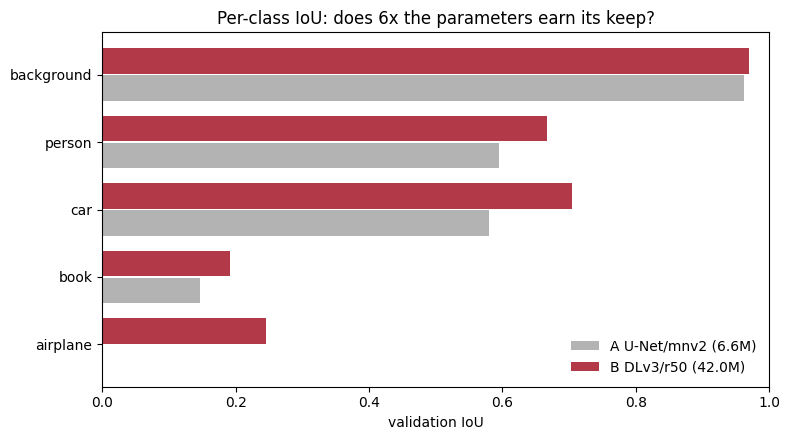


headline: 6.3x parameters bought +0.0989 mean IoU (0.4567 -> 0.5556)


In [10]:
# ================================================================
# I. Final validation sweep -> result table + comparison chart.
# ================================================================
final_a = evaluate(model_a, val_loader)
final_b = evaluate(model_b, val_loader)

rows = []
for c, name in enumerate(CLASS_NAMES):
    rows.append({
        "class": name,
        "IoU_unet_mnv2": round(float(final_a["iou"][c]), 4),
        "Dice_unet_mnv2": round(float(final_a["dice"][c]), 4),
        "IoU_dlv3_r50": round(float(final_b["iou"][c]), 4),
        "Dice_dlv3_r50": round(float(final_b["dice"][c]), 4),
    })
rows.append({
    "class": "MEAN",
    "IoU_unet_mnv2": round(final_a["miou"], 4),
    "Dice_unet_mnv2": round(final_a["mdice"], 4),
    "IoU_dlv3_r50": round(final_b["miou"], 4),
    "Dice_dlv3_r50": round(final_b["mdice"], 4),
})
result_table = pd.DataFrame(rows)
csv_path = ART_DIR / SETTINGS["out"]["table_csv"]
result_table.to_csv(csv_path, index=False)
print(result_table.to_string(index=False))
print("\nsaved ->", csv_path)

# Horizontal grouped bars: grey = featherweight A, accent = B.
fig, ax = plt.subplots(figsize=(8, 4.5))
ypos = np.arange(NUM_CLASSES)
ax.barh(ypos + 0.2, final_a["iou"], height=0.38, color=GREYS[1],
        label=f"A U-Net/mnv2 ({param_millions(model_a):.1f}M)")
ax.barh(ypos - 0.2, final_b["iou"], height=0.38, color=ACCENT,
        label=f"B DLv3/r50 ({param_millions(model_b):.1f}M)")
ax.set_yticks(ypos, CLASS_NAMES)
ax.invert_yaxis()
ax.set_xlabel("validation IoU")
ax.set_xlim(0, 1)
ax.legend(frameon=False, loc="lower right")
ax.set_title("Per-class IoU: does 6x the parameters earn its keep?")
plt.tight_layout(); plt.show()

# The headline trade-off, spelled out for the report:
gain = final_b["miou"] - final_a["miou"]
ratio = param_millions(model_b) / param_millions(model_a)
print(f"\nheadline: {ratio:.1f}x parameters bought "
      f"{gain:+.4f} mean IoU "
      f"({final_a['miou']:.4f} -> {final_b['miou']:.4f})")

## J. Predictions On Held-Out Test Images.

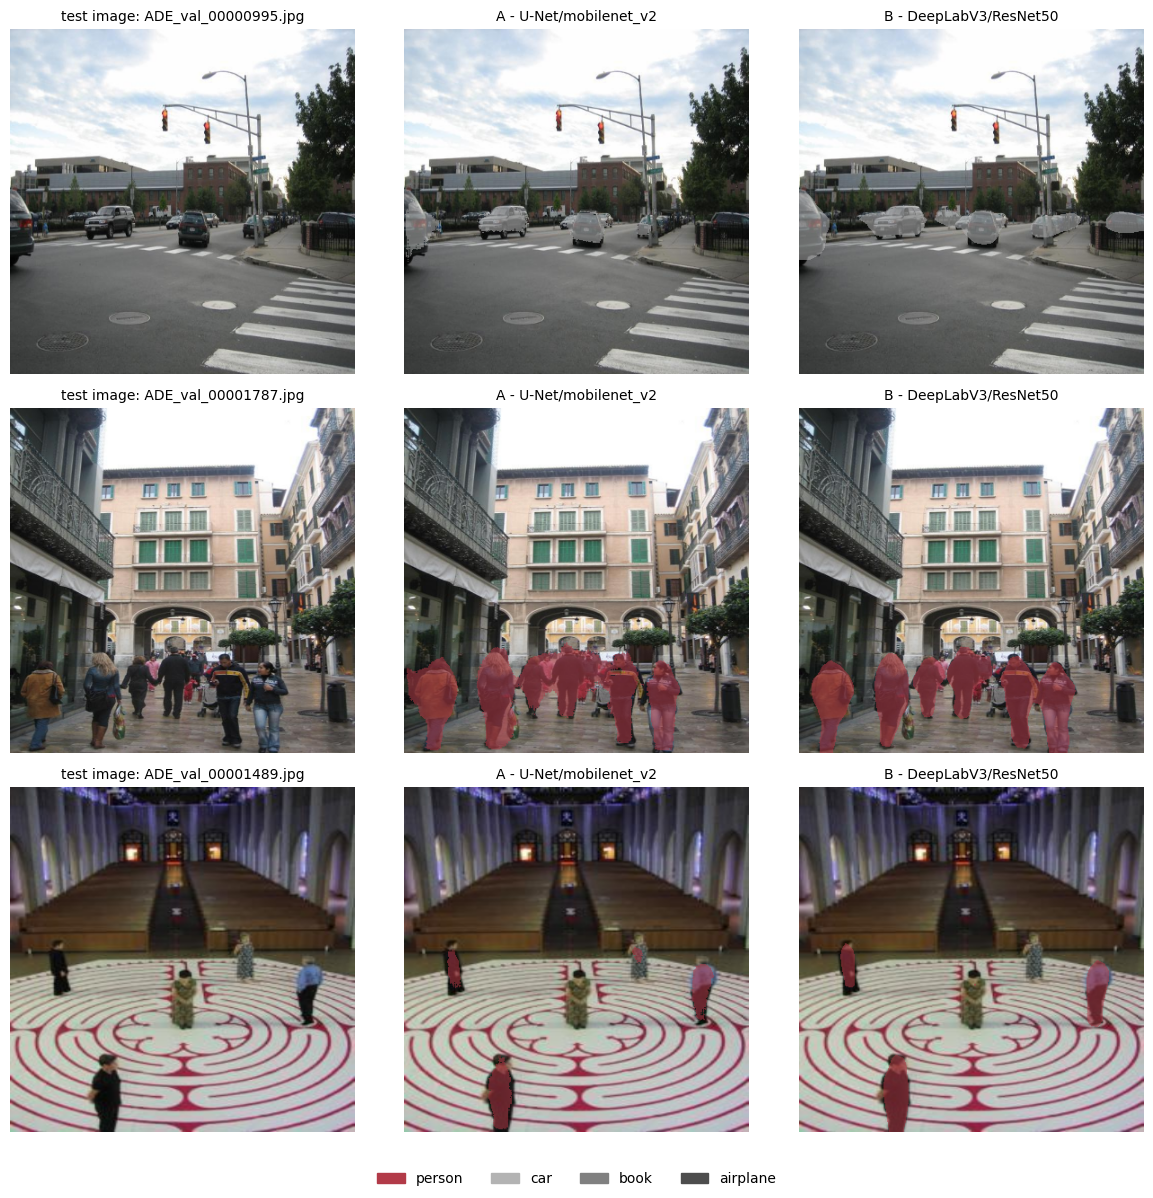

predicted: ADE_val_00000995.jpg
predicted: ADE_val_00001787.jpg
predicted: ADE_val_00001489.jpg


In [11]:
# ================================================================
# J. Qualitative check: 3 test images, both models side by side.
# ================================================================
# The test split ships without annotations, so this is a purely
# visual sanity check -- exactly what a practitioner does before
# trusting the numbers in section I.
picker = random.Random(SEED)          # seeded pick, stable on rerun
chosen = picker.sample(TEST_IMAGES, k=min(3, len(TEST_IMAGES)))
test_prep = PrepKit(IMG_SIZE, augment=False)


def colour_overlay(rgb, label_mask, alpha=0.55):
    """Blend the class palette over an RGB image (background stays)."""
    lut = np.zeros((NUM_CLASSES, 3), dtype=np.uint8)
    for c in range(1, NUM_CLASSES):
        col = CLASS_COLOURS[c]
        # matplotlib colour strings -> RGB triples for numpy blending
        lut[c] = (np.array(plt.matplotlib.colors.to_rgb(col)) * 255)
    painted = rgb.copy()
    fg = label_mask > 0
    painted[fg] = ((1 - alpha) * rgb[fg] + alpha * lut[label_mask[fg]]
                   ).astype(np.uint8)
    return painted


@torch.no_grad()
def predict_mask(model, bgr):
    x, _ = test_prep(bgr)
    logits = logits_of(model.eval(), x.unsqueeze(0).to(DEVICE))
    return logits.argmax(1)[0].cpu().numpy().astype(np.uint8)


fig, axes = plt.subplots(len(chosen), 3, figsize=(12, 4 * len(chosen)))
axes = np.atleast_2d(axes)
for row, path in enumerate(chosen):
    bgr = cv2.imread(str(path))
    rgb = cv2.cvtColor(cv2.resize(bgr, (IMG_SIZE, IMG_SIZE)),
                       cv2.COLOR_BGR2RGB)
    pred_a = predict_mask(model_a, bgr)
    pred_b = predict_mask(model_b, bgr)
    panels = [
        (rgb, f"test image: {path.name}"),
        (colour_overlay(rgb, pred_a), "A - U-Net/mobilenet_v2"),
        (colour_overlay(rgb, pred_b), "B - DeepLabV3/ResNet50"),
    ]
    for col, (img, title) in enumerate(panels):
        axes[row, col].imshow(img)
        axes[row, col].set_title(title, fontsize=10)
        axes[row, col].axis("off")
handles = [plt.Rectangle((0, 0), 1, 1, color=CLASS_COLOURS[c])
           for c in range(1, NUM_CLASSES)]
fig.legend(handles, CLASS_NAMES[1:], ncol=4, frameon=False,
           loc="lower center")
plt.tight_layout(rect=(0, 0.04, 1, 1)); plt.show()

for path in chosen:
    print("predicted:", path.name)

## K. Artifacts And Wrap-Up.

In [12]:
# ================================================================
# K. What this run leaves behind, and the one-line conclusion.
# ================================================================
print("artifact folder:", ART_DIR.name + "/")
for f in sorted(ART_DIR.iterdir()):
    print(f"  {f.name:24s} {f.stat().st_size / 1e6:8.2f} MB")

print("\nrun summary")
print(f"  seed {SEED} | image size {IMG_SIZE} | batch "
      f"{SETTINGS['train']['batch_size']} | focal gamma "
      f"{SETTINGS['train']['focal_gamma']}")
print(f"  A stopped after {state_a['epoch']} epochs "
      f"(best val mIoU {state_a['best']:.4f})")
print(f"  B stopped after {state_b['epoch']} epochs "
      f"(best val mIoU {state_b['best']:.4f})")
print(f"  parameter budget: {param_millions(model_a):.1f}M vs "
      f"{param_millions(model_b):.1f}M")
print("\nconclusion for the report: weigh the mean-IoU gap in section I")
print("against the ~6x parameter and compute bill of the heavyweight --")
print("on a 350-image corpus the featherweight is a serious contender.")

artifact folder: mnv2_vs_r50/
  dlv3_r50_tuned.pth         168.34 MB
  result_table.csv             0.00 MB
  unet_mnv2.pth               26.80 MB

run summary
  seed 2093 | image size 384 | batch 11 | focal gamma 2.0
  A stopped after 32 epochs (best val mIoU 0.4567)
  B stopped after 27 epochs (best val mIoU 0.5556)
  parameter budget: 6.6M vs 42.0M

conclusion for the report: weigh the mean-IoU gap in section I
against the ~6x parameter and compute bill of the heavyweight --
on a 350-image corpus the featherweight is a serious contender.
